In [389]:
import pandas as pd
import numpy as np
import scipy as sp
import scipy.spatial.distance as spd
import importlib

import plotly.express as px

import irina.utility_functions as uf

In [3]:
year = 2023

In [291]:
df_cs_indiv = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year), index_col=0)
df_cs_collab = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year), index_col=0)

In [292]:
df_cs_collab

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE,4.0,9.0,11.0,5.0,6.0,72.0,1.0,1.0,5.0,141.0,...,6.0,16.0,25.0,1.0,NaN,3.0,2.0,5.0,12.0,9.0
AF,5.0,4.0,1.0,NaN,2.0,6.0,NaN,NaN,3.0,15.0,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0,4.0,1.0
AG,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,1.0,3.0,4.0,3.0,NaN,6.0,NaN,NaN,1.0,7.0,...,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,2.0,5.0,3.0,3.0,4.0,11.0,NaN,NaN,3.0,26.0,...,5.0,1.0,3.0,2.0,NaN,NaN,NaN,1.0,3.0,NaN
ZA,42.0,49.0,41.0,21.0,162.0,96.0,13.0,NaN,75.0,307.0,...,3.0,21.0,14.0,7.0,NaN,20.0,7.0,6.0,29.0,19.0


In [293]:
df_stats = (
    pd.DataFrame(index=(df_cs_indiv.index.union(df_cs_collab.index)))
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region"]], left_index=True, right_on="alpha-2")
    .rename(columns={"alpha-2": "country"})
    .set_index("country")
)

# Jaccard dissimilarity

$$
Jaccard(A, B) = 1 - \dfrac{|A \cap B|}{|A \cup B|}
$$

In [311]:
country = "ID"

In [312]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard"] = spd.jaccard(df_cs_collab.loc[c] > 0, df_cs_indiv.loc[c] > 0)
    else:
        df_stats.loc[c, "jaccard"] = 1

In [313]:
df_stats

,alpha-3,name,region,w1_tree,cosine_0,jaccard
country,,,,,,
AD,AND,Andorra,Europe,0.246015,0.966888,0.950000
AE,ARE,United Arab Emirates,Asia,0.090023,0.405091,0.109244
AF,AFG,Afghanistan,Asia,0.254948,0.666378,0.429487
AG,ATG,Antigua and Barbuda,Americas,0.060591,0.488671,0.516129
AL,ALB,Albania,Europe,0.317118,0.736521,0.483333
...,...,...,...,...,...,...
WS,WSM,Samoa,Oceania,0.320659,0.761473,0.846154
YE,YEM,Yemen,Asia,0.237864,0.536222,0.309645
ZA,ZAF,South Africa,Africa,0.225471,0.323636,0.033058


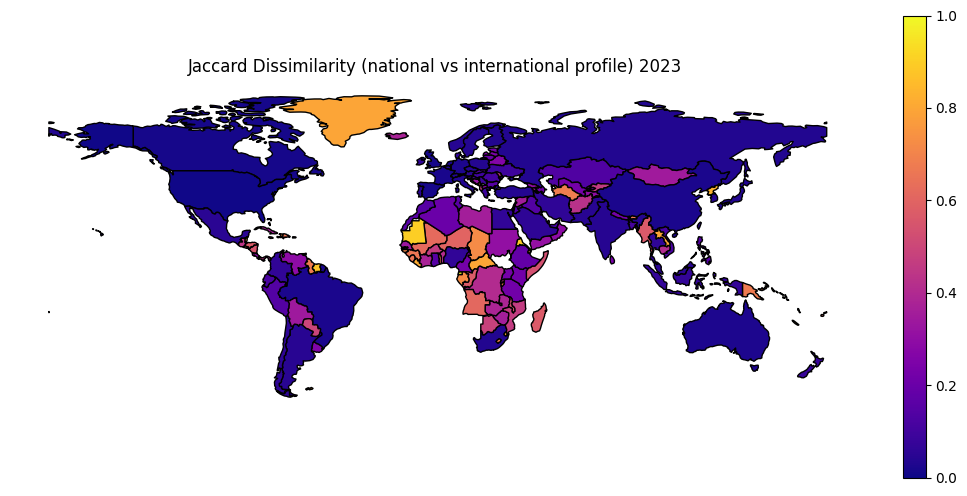

In [314]:
_, _ = uf.plot_map_continuous(df_stats, "jaccard", range=(0, 1), title=f"Jaccard Dissimilarity (national vs international profile) {year}")

In [315]:
def jaccard_turn(a, b):
    intersect = a == b
    outer_a = a[~intersect].sum()
    outer_b = b[~intersect].sum()
    return 2 * min(outer_a, outer_b) / (a[intersect].sum() + 2 * min(outer_a, outer_b))

In [316]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard_turn"] = jaccard_turn(df_cs_collab.loc[c] > 0, df_cs_indiv.loc[c] > 0)
    else:
        df_stats.loc[c, "jaccard_turn"] = 1

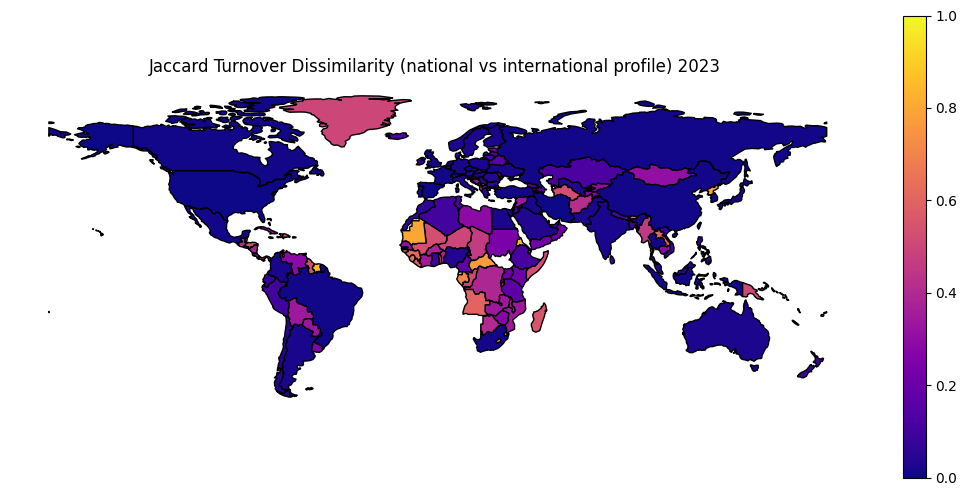

In [317]:
_, _ = uf.plot_map_continuous(df_stats, "jaccard_turn", range=(0, 1), title=f"Jaccard Turnover Dissimilarity (national vs international profile) {year}")

# Bray-Curtis



In [318]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "bray_curtis"] = spd.braycurtis(df_cs_collab.loc[c] > 0, df_cs_indiv.loc[c] > 0)
    else:
        df_stats.loc[c, "bray_curtis"] = 1

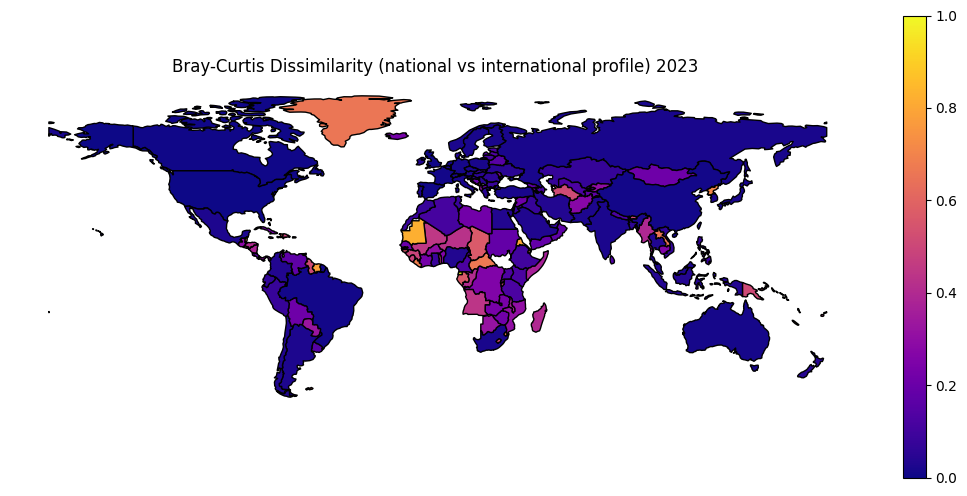

In [319]:
_, _ = uf.plot_map_continuous(df_stats, "bray_curtis", range=(0, 1), title=f"Bray-Curtis Dissimilarity (national vs international profile) {year}")

# Wasserstein-tree (probability)

In [294]:
w1_max = (
    uf.df_topics
    .sample(2)
)

In [295]:
df_prob_collab = df_cs_collab.div(df_cs_collab.sum(axis=1), axis=0)
df_prob_indiv = df_cs_indiv.div(df_cs_indiv.sum(axis=1), axis=0)

In [296]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [297]:
# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

In [298]:
_, _, w1_dist = uf.get_dist_w1_tree(subfield_tree, df_prob_collab.loc[country].dropna().to_dict(), df_prob_indiv.loc[country].dropna().to_dict())

In [299]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        _, _, df_stats.loc[c, "w1_tree"] = (uf.get_dist_w1_tree(subfield_tree, df_prob_collab.loc[c].dropna().to_dict(), df_prob_indiv.loc[c].dropna().to_dict())
                                            / w1_max)
    else:
        df_stats.loc[c, "w1_tree"] = np.nan

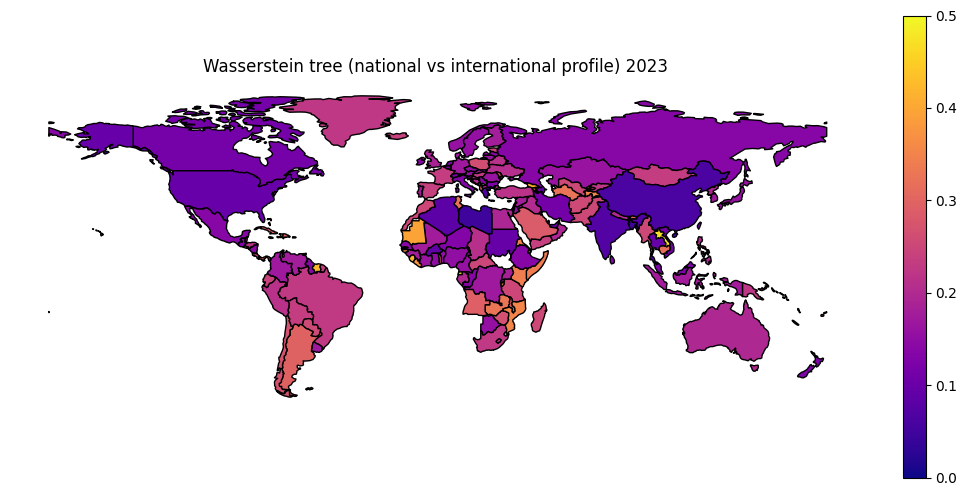

In [300]:
_, _ = uf.plot_map_continuous(df_stats, "w1_tree", title=f"Wasserstein tree (national vs international profile) {year}", range=(0, 0.5))

In [301]:
px.histogram(df_stats, x="w1_tree")

# Cosine

In [351]:
df_global = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").query("year == @year")
df_global.subfield_id = df_global.subfield_id.astype(int)
df_global = (
    df_global
    .set_index("subfield_id")
    .assign(
        z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
        z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
    )
)


In [303]:
df_global

,counts_all,counts_individual,counts_collab,probability_all,probability_individual,probability_collab,counts_individual_pct,counts_collab_pct,year
subfield_id,,,,,,,,,
1100,14421,13100,1321.0,0.003050,0.003311,0.001710,90.839748,9.160252,2023
1102,10972,9174,1798.0,0.002320,0.002319,0.002328,83.612833,16.387167,2023
1103,9755,7988,1767.0,0.002063,0.002019,0.002288,81.886212,18.113788,2023
1104,8204,7009,1195.0,0.001735,0.001772,0.001547,85.433935,14.566065,2023
1105,20232,15045,5187.0,0.004279,0.003803,0.006716,74.362396,25.637604,2023
...,...,...,...,...,...,...,...,...,...
3609,6589,6066,523.0,0.001393,0.001533,0.000677,92.062528,7.937472,2023
3611,3130,2782,348.0,0.000662,0.000703,0.000451,88.881789,11.118211,2023
3612,8603,7834,769.0,0.001819,0.001980,0.000996,91.061258,8.938742,2023


In [304]:
df_global.probability_collab.to_frame("Global").T

subfield_id,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
Global,0.00171,0.002328,0.002288,0.001547,0.006716,0.006471,0.000651,0.000102,0.003316,0.019309,...,0.000388,0.001312,0.001012,0.000128,0.000006,0.000677,0.000451,0.000996,0.001143,0.001169


In [305]:
df_im_collab = np.log(df_prob_collab.div(df_global["probability_collab"].values, axis="columns"))
df_im_indiv = np.log(df_prob_indiv.div(df_global["probability_individual"].values, axis="columns"))

In [306]:
spd.cosine(df_im_collab.loc[country].fillna(0), df_im_indiv.loc[country].fillna(0))

np.float64(1.0)

In [307]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "cosine_0"] = min(spd.cosine(df_im_collab.loc[c].fillna(0), df_im_indiv.loc[c].fillna(0)), 1)
    else:
        df_stats.loc[c, "cosine_0"] = np.nan



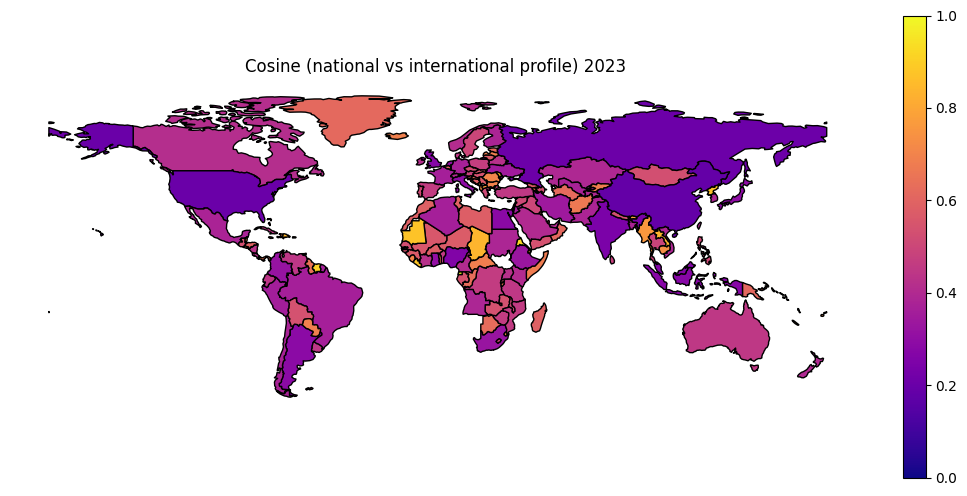

In [308]:
_, _ = uf.plot_map_continuous(df_stats, "cosine_0", title=f"Cosine (national vs international profile) {year}", range=(0, 1))

# Compare boxplots

In [323]:
metrics = ["jaccard", "jaccard_turn", "bray_curtis", "w1_tree", "cosine_0"]

In [324]:
df_stats

,alpha-3,name,region,w1_tree,cosine_0,jaccard,jaccard_turn,bray_curtis
country,,,,,,,,
AD,AND,Andorra,Europe,0.246015,0.966888,0.950000,0.909091,0.904762
AE,ARE,United Arab Emirates,Asia,0.090023,0.405091,0.109244,0.070175,0.057778
AF,AFG,Afghanistan,Asia,0.254948,0.666378,0.429487,0.410596,0.273469
AG,ATG,Antigua and Barbuda,Americas,0.060591,0.488671,0.516129,0.210526,0.347826
AL,ALB,Albania,Europe,0.317118,0.736521,0.483333,0.415094,0.318681
...,...,...,...,...,...,...,...,...
WS,WSM,Samoa,Oceania,0.320659,0.761473,0.846154,0.714286,0.733333
YE,YEM,Yemen,Asia,0.237864,0.536222,0.309645,0.218391,0.183183
ZA,ZAF,South Africa,Africa,0.225471,0.323636,0.033058,0.008475,0.016807


In [325]:
df_box = (df_stats.reset_index().melt(id_vars=["country", "alpha-3", "name", "region"], var_name="metric", value_vars=metrics, value_name="value"))

In [326]:
df_box

,country,alpha-3,name,region,metric,value
0,AD,AND,Andorra,Europe,jaccard,0.950000
1,AE,ARE,United Arab Emirates,Asia,jaccard,0.109244
2,AF,AFG,Afghanistan,Asia,jaccard,0.429487
3,AG,ATG,Antigua and Barbuda,Americas,jaccard,0.516129
4,AL,ALB,Albania,Europe,jaccard,0.483333
...,...,...,...,...,...,...
1080,WS,WSM,Samoa,Oceania,cosine_0,0.761473
1081,YE,YEM,Yemen,Asia,cosine_0,0.536222
1082,ZA,ZAF,South Africa,Africa,cosine_0,0.323636
1083,ZM,ZMB,Zambia,Africa,cosine_0,0.535669


In [327]:
px.box(
    df_box,
    x="metric",
    y="value",
    points="all",
    hover_data=["country", "name", "region"],
    title="Dissimilarity measurement comparison: 0 -- the same, 1 -- distant",
    color="metric"
)

In [334]:
px.histogram(
    df_stats,
    x=metrics,
    barmode="group",
)

In [404]:
metric = ["w1_tree", "jaccard"]
px.bar(df_stats.sort_values(metric), x="alpha-3", y=metric, hover_data=["alpha-3", "name", "region"], barmode="group")

In [430]:
px.scatter(
    df_stats,
    x="jaccard",
    y="w1_tree",
    color="region",
    hover_data=["alpha-3", "name", "region"],
)

In [392]:
px.bar(df_stats.loc[uf.top_n_countries_by_articles(15)], x="name", y=metrics, barmode="group")

In [409]:
uf.get_country_info("KI")

,name,region,sub-region,code
117,Kiribati,Oceania,Micronesia,KI


In [428]:
country = "PL"
df_profile_country = pd.concat([
    df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
])
px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay")

In [429]:
country = "SE"
df_profile_country = pd.concat([
    df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
])
px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay")

In [427]:
uf.get_subfield_info(3312)

,subfield_id,subfield_name,field_name,domain_name
54,3312,Sociology and Political Science,Social Sciences,Social Sciences


In [373]:
df_stats.loc["US"]

alpha-3                              USA
name            United States of America
region                          Americas
w1_tree                         0.097569
cosine_0                        0.201349
jaccard                         0.003984
jaccard_turn                         0.0
bray_curtis                     0.001996
Name: US, dtype: object

# Compare global

In [347]:
spd.jaccard(df_global.counts_individual > 0, df_global.counts_collab > 0)

np.float64(0.0)

In [364]:
uf.get_dist_w1_tree(subfield_tree,
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_individual.dropna().to_dict(),
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_collab.dropna().to_dict())

(np.float64(0.9999999999999885),
 np.float64(0.9999999999999891),
 np.float64(0.2313409774457337))

In [358]:
px.bar(df_global, x=df_global.index.astype(str), y=["probability_individual", "probability_collab"], barmode="overlay")

In [360]:
sp.special.kl_div(df_global.probability_individual, df_global.probability_collab).sum()

np.float64(0.0921665547252884)

# Compare close to global

In [431]:
global_dict_indiv = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_individual
    .dropna()
    .to_dict()
)
global_dict_collab = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_collab
    .dropna()
    .to_dict()
)


In [432]:
df_global

,counts_all,counts_individual,counts_collab,probability_all,probability_individual,probability_collab,counts_individual_pct,counts_collab_pct,year,z_score_individual,z_score_collab
subfield_id,,,,,,,,,,,
1100,14421,13100,1321.0,0.003050,0.003311,0.001710,90.839748,9.160252,2023,-0.116805,-0.395417
1102,10972,9174,1798.0,0.002320,0.002319,0.002328,83.612833,16.387167,2023,-0.293254,-0.287264
1103,9755,7988,1767.0,0.002063,0.002019,0.002288,81.886212,18.113788,2023,-0.346558,-0.294293
1104,8204,7009,1195.0,0.001735,0.001772,0.001547,85.433935,14.566065,2023,-0.390557,-0.423985
1105,20232,15045,5187.0,0.004279,0.003803,0.006716,74.362396,25.637604,2023,-0.029389,0.481140
...,...,...,...,...,...,...,...,...,...,...,...
3609,6589,6066,523.0,0.001393,0.001533,0.000677,92.062528,7.937472,2023,-0.432939,-0.576351
3611,3130,2782,348.0,0.000662,0.000703,0.000451,88.881789,11.118211,2023,-0.580535,-0.616030
3612,8603,7834,769.0,0.001819,0.001980,0.000996,91.061258,8.938742,2023,-0.353479,-0.520574


In [486]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

In [490]:
# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

uf.get_jaccard(df_stats, df_cs_collab, df_global, col_name="jaccard_gl_collab", col_df2="counts_collab")
uf.get_jaccard(df_stats, df_cs_indiv, df_global, col_name="jaccard_gl_indiv", col_df2="counts_individual")

uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_collab, dict2=global_dict_collab, col_name="w1_tree_gl_collab")
uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_indiv, dict2=global_dict_indiv, col_name="w1_tree_gl_indiv", w1_max=w1_max)

In [491]:
df_stats

,alpha-3,name,region,w1_tree,cosine_0,jaccard,jaccard_turn,bray_curtis,jaccard_gl_collab,jaccard_gl_indiv,w1_tree_gl_indiv,w1_tree_gl_collab,jaccard_test,jaccard_test_gl
country,,,,,,,,,,,,,,
AD,AND,Andorra,Europe,0.246015,0.966888,0.950000,0.909091,0.904762,0.940476,0.976190,0.197889,0.599320,0.950000,0.940476
AE,ARE,United Arab Emirates,Asia,0.090023,0.405091,0.109244,0.070175,0.057778,0.087302,0.126984,0.117456,0.254528,0.109244,0.087302
AF,AFG,Afghanistan,Asia,0.254948,0.666378,0.429487,0.410596,0.273469,0.523810,0.503968,0.300161,0.452321,0.429487,0.523810
AG,ATG,Antigua and Barbuda,Americas,0.060591,0.488671,0.516129,0.210526,0.347826,0.654762,0.797619,0.564217,1.212108,0.516129,0.654762
AL,ALB,Albania,Europe,0.317118,0.736521,0.483333,0.415094,0.318681,0.500000,0.416667,0.295355,0.308863,0.483333,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,WSM,Samoa,Oceania,0.320659,0.761473,0.846154,0.714286,0.733333,0.916667,0.964286,0.525891,0.896326,0.846154,0.916667
YE,YEM,Yemen,Asia,0.237864,0.536222,0.309645,0.218391,0.183183,0.293651,0.384921,0.176838,0.126096,0.309645,0.293651
ZA,ZAF,South Africa,Africa,0.225471,0.323636,0.033058,0.008475,0.016807,0.067460,0.043651,0.186722,0.182331,0.033058,0.067460


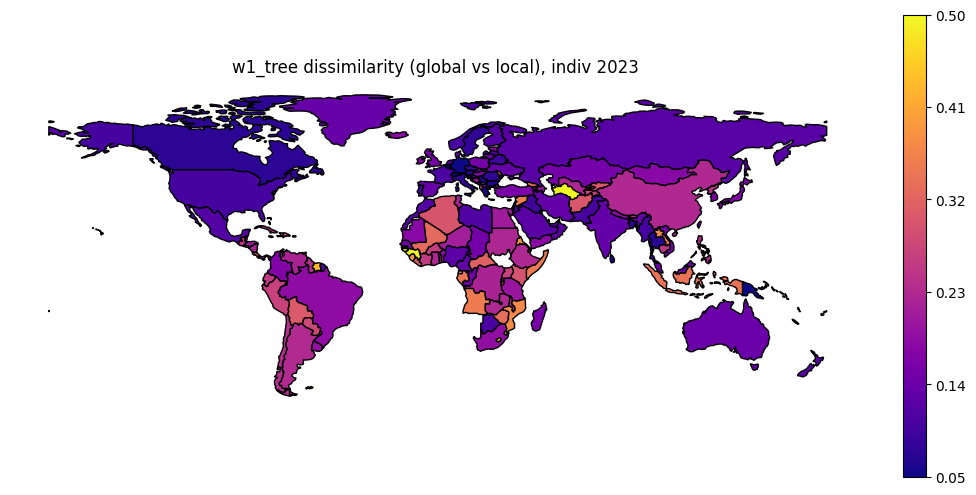

In [492]:
mode = "w1_tree"
regime = "indiv"
_, _ = uf.plot_map_continuous(df_stats, f"{mode}_gl_{regime}", title=f"{mode} dissimilarity (global vs local), {regime} {year}", range=(0.05, 0.5))

In [458]:
px.histogram(
    df_stats,
    x=["jaccard_gl_collab", "jaccard_gl_indiv"],
    histnorm="probability",
    nbins=50,
    barmode="group",
)

In [455]:
df_box_gl = (df_stats.reset_index().melt(id_vars=["country", "alpha-3", "name", "region"],
                                         var_name="metric",
                                         value_vars=["w1_tree_gl_indiv", "w1_tree_gl_collab", "jaccard_gl_collab", "jaccard_gl_indiv"], value_name="value"))

In [457]:
px.box(
    df_box_gl,
    x="metric",
    y="value",
    points="all",
    hover_data=["alpha-3", "name", "region"],
    color="metric",
    title="Dissimilarity comparison: local vs global"
)

In [465]:
px.scatter(
    df_stats,
    x="jaccard_gl_collab",
    y="w1_tree_gl_collab",
    hover_data=["alpha-3", "name", "region"],
    color="region"
)

In [466]:
px.scatter(
    df_stats,
    x="jaccard_gl_indiv",
    y="w1_tree_gl_indiv",
    hover_data=["alpha-3", "name", "region"],
    color="region"
)

# Pipeline yearly



In [ ]:
# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

uf.get_jaccard(df_stats, df_cs_collab, df_global, col_name="jaccard_gl_collab", col_df2="counts_collab")
uf.get_jaccard(df_stats, df_cs_indiv, df_global, col_name="jaccard_gl_indiv", col_df2="counts_individual")

uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_collab, dict2=global_dict_collab, col_name="w1_tree_gl_collab")
uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_indiv, dict2=global_dict_indiv, col_name="w1_tree_gl_indiv", w1_max=w1_max)

In [511]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

In [517]:
start_year = 1970
end_year = 2023

subfield1 = "2713"
subfield2 = "1904"

_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

df_stats_list = []
for year_loop in range(start_year, end_year+1):
    try:
        df_cs_indiv_loop = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year_loop), index_col=0)
        df_cs_collab_loop = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year_loop), index_col=0)

        all_cols = df_cs_indiv_loop.columns.union(df_cs_collab_loop.columns)

        df_cs_collab_loop = df_cs_collab_loop.reindex(columns=all_cols)
        df_cs_indiv_loop = df_cs_indiv_loop.reindex(columns=all_cols)

        df_global_loop = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").drop_duplicates().query("year == @year_loop")
        df_global_loop.subfield_id = df_global_loop.subfield_id.astype(int)
        df_global_loop = (
            df_global_loop
            .set_index("subfield_id")
            .assign(
                z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
                z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
            )
        )

        global_dict_indiv_loop = (
        df_global_loop
        .reset_index("subfield_id")
        .assign(subfield_str=lambda df: df.subfield_id.astype(str))
        .set_index("subfield_str")
        .probability_individual
        .dropna()
        .to_dict()
        )
        global_dict_collab_loop = (
            df_global_loop
            .reset_index("subfield_id")
            .assign(subfield_str=lambda df: df.subfield_id.astype(str))
            .set_index("subfield_str")
            .probability_collab
            .dropna()
            .to_dict()
        )

        df_prob_collab_loop = df_cs_collab.div(df_cs_collab.sum(axis=1), axis=0)
        df_prob_indiv_loop = df_cs_indiv.div(df_cs_indiv.sum(axis=1), axis=0)

        df_stats_loop = (
            pd.DataFrame(index=(df_cs_indiv_loop.index.union(df_cs_collab_loop.index)))
            .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region"]], left_index=True, right_on="alpha-2")
            .rename(columns={"alpha-2": "country"})
            .set_index("country")
            .assign(year=year_loop)
        )

        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_cs_indiv_loop, col_name="jaccard")
        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_global_loop, col_name="jaccard_gl_collab", col_df2="counts_collab")
        uf.get_jaccard(df_stats_loop, df_cs_indiv_loop, df_global_loop, col_name="jaccard_gl_indiv", col_df2="counts_individual")

        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, df2=df_prob_indiv_loop, col_name="w1_tree")
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, dict2=global_dict_collab_loop, col_name="w1_tree_gl_collab")
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_indiv_loop, dict2=global_dict_indiv_loop, col_name="w1_tree_gl_indiv", w1_max=w1_max)

        df_stats_list.append(df_stats_loop)
    except Exception as e:
        print(year_loop, e)

In [525]:
# pd.concat(df_stats_list).reset_index().to_csv("df_stats_national_international_1970_2023.csv", index=False)

In [526]:
df_stats_dyn = pd.concat(df_stats_list).reset_index()

In [527]:
df_stats_dyn

,country,alpha-3,name,region,year,jaccard,jaccard_gl_collab,jaccard_gl_indiv,w1_tree,w1_tree_gl_collab,w1_tree_gl_indiv
0,AE,ARE,United Arab Emirates,Asia,1970,0.851852,0.959641,0.912351,0.199850,0.329084,0.155946
1,AF,AFG,Afghanistan,Asia,1970,1.000000,0.995516,0.980080,0.565983,0.637452,0.382523
2,AG,ATG,Antigua and Barbuda,Americas,1970,1.000000,0.995516,1.000000,0.134512,1.286153,0.588608
3,AL,ALB,Albania,Europe,1970,1.000000,0.995516,1.000000,0.704002,0.503595,0.365072
4,AM,ARM,Armenia,Asia,1970,0.928571,0.959641,0.856574,0.667322,0.152592,0.249232
...,...,...,...,...,...,...,...,...,...,...,...
10800,WS,WSM,Samoa,Oceania,2023,0.846154,0.916667,0.964286,0.711863,0.896326,0.525891
10801,YE,YEM,Yemen,Asia,2023,0.309645,0.293651,0.384921,0.528059,0.126096,0.176838
10802,ZA,ZAF,South Africa,Africa,2023,0.033058,0.067460,0.043651,0.500546,0.182331,0.186722
10803,ZM,ZMB,Zambia,Africa,2023,0.382022,0.404762,0.452381,0.732417,0.684545,0.225940


In [546]:
country_list = ["US", "CN", "RU", "ID", "GB", "FR", "CA", "KR", "BR"]
px.line(
    df_stats_dyn.query("country in @country_list"),
    x="year",
    y="w1_tree_gl_indiv",
    color="country"
)